# CS345 Spring 2026 Final Project - Maggie Ring
# UNSW-NB15 for malicious network traffic classification

## Introduction

I have a strong interest in cybersecrutiy, so for my project I wanted to explore how machine learning can be used to identify malicious network traffic for anomaly-based intrusion detection and prevention systems. The dataset I will be using is the [UNSW-NB15](https://research.unsw.edu.au/projects/unsw-nb15-dataset). It was created in 2015 at the University of New South Wales Canberra's Cyber Range lab. It contains a mix of normal and malicous network activity collected using the IXIA PerfectStorm tool. The malicious activity is categorized into 9 types (Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode and Worms). There are 42 features for things like protocol, time to live values, sequence numbers, etc. There are 257,673 records in total.

<details>
  <summary>All features</summary>
      <ul>
    Name,Type ,Description
    <li>srcip,nominal,Source IP address</li>
    <li>sport,integer,Source port number</li>
    <li>dstip,nominal,Destination IP address</li>
    <li>dsport,integer,Destination port number</li>
    <li>proto,nominal,Transaction protocol</li>
    <li>state,nominal,"Indicates to the state and its dependent protocol, e.g. ACC, CLO, CON, ECO, ECR, FIN, INT, MAS, PAR, REQ, RST, TST, TXD, URH, URN, and (-) (if not used state)"</li>
    <li>dur,Float,Record total duration</li>
    <li>sbytes,Integer,Source to destination transaction bytes </li>
    <li>dbytes,Integer,Destination to source transaction bytes</li>
    <li>sttl,Integer,Source to destination time to live value </li>
    <li>dttl,Integer,Destination to source time to live value</li>
    <li>sloss,Integer,Source packets retransmitted or dropped </li>
    <li>dloss,Integer,Destination packets retransmitted or dropped</li>
    <li>service,nominal,"http, ftp, smtp, ssh, dns, ftp-data ,irc  and (-) if not much used service"</li>
    <li>Sload,Float,Source bits per second</li>
    <li>Dload,Float,Destination bits per second</li>
    <li>Spkts,integer,Source to destination packet count </li>
    <li>Dpkts,integer,Destination to source packet count</li>
    <li>swin,integer,Source TCP window advertisement value</li>
    <li>dwin,integer,Destination TCP window advertisement value</li>
    <li>stcpb,integer,Source TCP base sequence number</li>
    <li>dtcpb,integer,Destination TCP base sequence number</li>
    <li>smeansz,integer,Mean of the ?ow packet size transmitted by the src </li>
    <li>dmeansz,integer,Mean of the ?ow packet size transmitted by the dst </li>
    <li>trans_depth,integer,Represents the pipelined depth into the connection of http request/response transaction</li>
    <li>res_bdy_len,integer,Actual uncompressed content size of the data transferred from the server�s http service.</li>
    <li>Sjit,Float,Source jitter (mSec)</li>
    <li>Djit,Float,Destination jitter (mSec)</li>
    <li>Stime,Timestamp,record start time</li>
    <li>Ltime,Timestamp,record last time</li>
    <li>Sintpkt,Float,Source interpacket arrival time (mSec)</li>
    <li>Dintpkt,Float,Destination interpacket arrival time (mSec)</li>
    <li>tcprtt,Float,"TCP connection setup round-trip time, the sum of synack and ackdat."</li>
    <li>synack,Float,"TCP connection setup time, the time between the SYN and the SYN_ACK packets."</li>
    <li>ackdat,Float,"TCP connection setup time, the time between the SYN_ACK and the ACK packets."</li>
    <li>is_sm_ips_ports,Binary,"If source (1) and destination (3)IP addresses equal and port numbers (2)(4)  equal then, this variable takes value 1 else 0"</li>
    <li>ct_state_ttl,Integer,No. for each state (6) according to specific range of values for source/destination time to live (10) (11).</li>
    <li>ct_flw_http_mthd,Integer,No. of flows that has methods such as Get and Post in http service.</li>
    <li>is_ftp_login,Binary,If the ftp session is accessed by user and password then 1 else 0. </li>
    <li>ct_ftp_cmd,integer,No of flows that has a command in ftp session.</li>
    <li>ct_srv_src,integer,No. of connections that contain the same service (14) and source address (1) in 100 connections according to the last time (26).</li>
    <li>ct_srv_dst,integer,No. of connections that contain the same service (14) and destination address (3) in 100 connections according to the last time (26).</li>
    <li>ct_dst_ltm,integer,No. of connections of the same destination address (3) in 100 connections according to the last time (26).</li>
    <li>ct_src_ ltm,integer,No. of connections of the same source address (1) in 100 connections according to the last time (26).</li>
    <li>ct_src_dport_ltm,integer,No of connections of the same source address (1) and the destination port (4) in 100 connections according to the last time (26).</li>
    <li>ct_dst_sport_ltm,integer,No of connections of the same destination address (3) and the source port (2) in 100 connections according to the last time (26).</li>
    <li>ct_dst_src_ltm,integer,No of connections of the same source (1) and the destination (3) address in in 100 connections according to the last time (26).</li>
    <li>attack_cat,nominal,"The name of each attack category. In this data set , nine categories e.g. Fuzzers, Analysis, Backdoors, DoS Exploits, Generic, Reconnaissance, Shellcode and Worms"</li>
    <li>Label,binary,0 for normal and 1 for attack records</li>
</details>

I will start by analyzing the data and preprocessing it. Next I will train my baseline (SVM) and models (random forest and multi layer perceptron (MLP)) on the binary classification of benign or malicious and analyze the results.

## Understanding the data

Before starting I will get a good understanding of the data so I have some clues on what models will work well and what techniques need to be used.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import make_scorer, accuracy_score, balanced_accuracy_score, f1_score, fbeta_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import classification_report

def get_subsample(X, y, size=10000, random_state=2):
    np.random.seed(random_state)
    idx = np.random.choice(len(X), size=size, replace=False)
    return X[idx], y[idx]

def make_splits(X, y, random_state=2):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.5, random_state=random_state, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.6, random_state=random_state, stratify=y_temp)
    return X_train, X_val, X_test, y_train, y_val, y_test

In [16]:
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('UNSW_NB15_testing-set.csv')

#combining training and testing sets so that I can do k fold cross validation instead
df = pd.concat([train_df, test_df], ignore_index=True)
print(f"shape: {df.shape}\n")

#count class distribution
class_counts = df['label'].value_counts().sort_index()
class_labels = ['benign (0)', 'malicious (1)']
class_pcts   = class_counts / len(df) * 100

print("class distribution:")
print(f"{class_labels[0]}: {class_counts.iloc[0]:,} ({class_pcts.iloc[0]:.1f}%)")
print(f"{class_labels[1]}: {class_counts.iloc[1]:,} ({class_pcts.iloc[1]:.1f}%)")

shape: (257673, 45)

class distribution:
benign (0): 93,000 (36.1%)
malicious (1): 164,673 (63.9%)


I added the training and testing sets together because I want to do k fold cross validation later on instead of using just one train and test split.

Because this dataset is somewhat large I have smaller sample sizes set up for testing, but have used the full data for my analysis.

The class distribution is slightly unbalanced (36.1% benign traffic and 63.9% malicious traffic) so I will use stratified k fold cross validation to make sure the class distribution is even among the train and test splits.

<br>

Now I will get the data ready to use:

In [17]:
#encode categorical columns
cat_cols = ['proto', 'service', 'state']
le = LabelEncoder()
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

#separate features and label
feature_cols = [c for c in df.columns if c not in ['id', 'attack_cat', 'label']]
X = df_enc[feature_cols].values
y = df_enc['label'].values

#standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

There were some categorical columns like protocol and service that needed to be encoded.

After that I seperated the features and the labels (id, attack category, and label (benign or malicious)).

Next I standardized the data so that features on a larger scale weren't given extra importance (move all features to the same scale).

<br>

Now I will do principle component analysis (PCA) to visualze the data and see how easy it looks to seperate (like if it is linearly seperable but I doubt it will be):

variance:
PC1: 23.0%
PC2: 9.6%
PC3: 8.6%
PC4: 7.8%
total variance of PC1-4: 49.0%


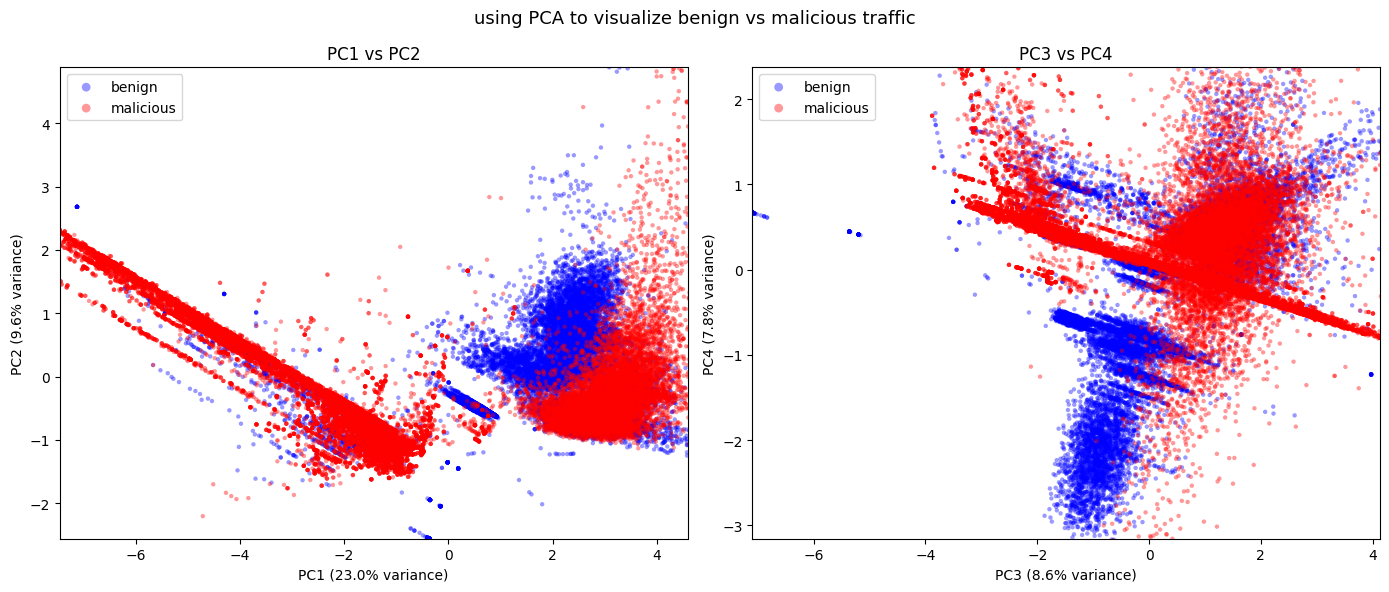

In [18]:
#get a smaller sample since its just for pca and visualization and not real training
X_sample, y_sample = get_subsample(X_scaled, y, size=50000, random_state=2)

#get 4 principle components so we can visualze the data as two graphs
pca4 = PCA(n_components=4, random_state=2)
X_pca4 = pca4.fit_transform(X_sample)

print(f"variance:")
print(f"PC1: {pca4.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca4.explained_variance_ratio_[1]*100:.1f}%")
print(f"PC3: {pca4.explained_variance_ratio_[2]*100:.1f}%")
print(f"PC4: {pca4.explained_variance_ratio_[3]*100:.1f}%")
print(f"total variance of PC1-4: {sum(pca4.explained_variance_ratio_)*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pc_pairs = [(0, 1), (2, 3)]
titles   = ['PC1 vs PC2', 'PC3 vs PC4']

for ax, (pc_x, pc_y), title in zip(axes, pc_pairs, titles):
    for class_val, color, label in zip([0, 1], ['blue', 'red'], ['benign', 'malicious']):
        mask = y_sample == class_val
        ax.scatter(X_pca4[mask, pc_x], X_pca4[mask, pc_y],
                   c=color, label=label,
                   alpha=0.4, s=10, edgecolors='none')

    #make the graph closer: before this some outliers were making it super zoomed out
    ax.set_xlim(np.percentile(X_pca4[:, pc_x], 1), np.percentile(X_pca4[:, pc_x], 99))
    ax.set_ylim(np.percentile(X_pca4[:, pc_y], 1), np.percentile(X_pca4[:, pc_y], 99))

    ev = pca4.explained_variance_ratio_
    ax.set_xlabel(f'PC{pc_x+1} ({ev[pc_x]*100:.1f}% variance)')
    ax.set_ylabel(f'PC{pc_y+1} ({ev[pc_y]*100:.1f}% variance)')
    ax.set_title(title)
    ax.legend(markerscale=2)

plt.suptitle('using PCA to visualize benign vs malicious traffic', fontsize=13)
plt.tight_layout()
plt.show()

The top 4 principle components are only capturing 49% of the variance which implies that there are many important features in the dataset so I likely won't want to reduce the dimensionality before training.

Looking at the graphs reveals that the data is not linearly seperable and a non linear classifier will be needed. A big reason for this is the malicious traffic clustering in multiple different areas because the malicious traffic includes different types of attacks which can have very different features associated with them.

There is also a lot of overlap between the two classes / the data is generally noisy. Because of this I will be cautious of overfitting.

<br>

Now I will do principle component analysis (PCA) to see if reducing the dimensionality of the data will make it perform better (using SVM for my baseline):

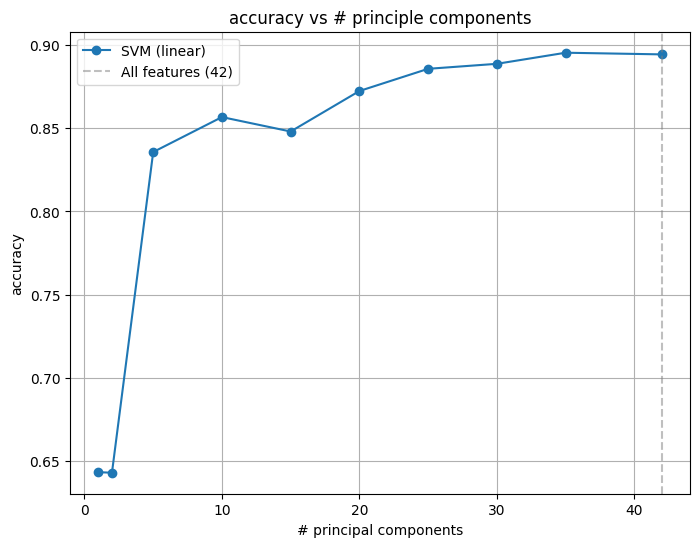

In [19]:
#using a smaller sample
X_sub, y_sub = get_subsample(X_scaled, y, size=10000, random_state=2)

X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=0.3,
    random_state=2,
    #stratify because classes are a bit unbalanced
    stratify=y_sub
)

components_list = [1, 2, 5, 10, 15, 20, 25, 30, 35, 42]
svm_results = []

for n in components_list:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)

    svm = SVC(kernel="linear", C=0.1)
    svm.fit(X_train_pca, y_train)
    svm_results.append(accuracy_score(y_test, svm.predict(X_test_pca)))

plt.figure(figsize=(8, 6))
plt.plot(components_list, svm_results, marker='o', label='SVM (linear)')
plt.axvline(x=42, color='gray', linestyle='--', alpha=0.5, label='All features (42)')
plt.xlabel('# principal components')
plt.ylabel('accuracy')
plt.title('accuracy vs # principle components')
plt.legend()
plt.grid(True)
plt.show()

Looking at the graph it appears that using all of the features (42) results in the highest accuracy. This makes sense considering the top 4 principle components only captured 49% of the variance. It also makes sense because the data is not very high dimensional to begin with.

Because of these results I won't be using reducing the dimensionality of the data before training and testing.

<br>

Now lets start with our baseline. I will be using a non linear SVM as the baseline with a RBF kernel:

## Baseline: SVM

In [20]:
#using straified k fold because the classes are a bit unbalanced
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

scoring = {
    'accuracy': make_scorer(accuracy_score),
    #using balanced accuracy because the classes are a bit unbalanced
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    #using fbeta because it weighs recall more than precision
    'fbeta': make_scorer(fbeta_score, beta=1.5),
}

svm_baseline = SVC(kernel='rbf', random_state=2)

#using a smaller sample so it doesn't take hours
X_eval, y_eval = get_subsample(X_scaled, y, size=10000, random_state=2)

svm_results = cross_validate(svm_baseline, X_eval, y_eval,
                             cv=cv,
                             scoring=scoring,
                             return_train_score=False)

print("baseline (SVM) scores:")
print(f"accuracy: {svm_results['test_accuracy'].mean():.4f}")
print(f"balanced accuracy: {svm_results['test_balanced_accuracy'].mean():.4f}")
print(f"recall: {svm_results['test_recall'].mean():.4f}")
print(f"precision: {svm_results['test_precision'].mean():.4f}")
print(f"f1: {svm_results['test_f1'].mean():.4f}")
print(f"fbeta: {svm_results['test_fbeta'].mean():.4f}")

baseline (SVM) scores:
accuracy: 0.9028
balanced accuracy: 0.8671
recall: 0.9877
precision: 0.8778
f1: 0.9295
fbeta: 0.9510


The recall is already fairly high (.9877) for the baseline and the balanced accuracy is somewhat low (.8671). High recall at the expensive of accuracy can be ok in high security envirnments where it is ok to have some false positives in order to catch a high percentage of malicious traffic. For many other envirnments, recall and accuracy should be more balanced to ensure availability as well as security.

<br>

Now I will train random forest and MLP on the dataset. I will start by doing hyperparameter selection so that I can find the best hyperparameters to use. I will score using fbeta with a beta of 1.5 so that recall is weighed a bit more than precision.

## Random forest and MLP: hyperparameter selection

In [21]:
def best_params_on_val(model_class, param_grid, X_train, y_train, X_val, y_val, random_state=2):
    best_params = None
    best_score  = 0
    for params in param_grid:
        model = model_class(**params, random_state=random_state)
        model.fit(X_train, y_train)
        score = fbeta_score(y_val, model.predict(X_val), beta=1.5)
        if score > best_score:
            best_score  = score
            best_params = params
    return best_params

def run_param_search(model_class, param_grid, X_scaled, y, n_iter=10, subsample_size=10000):
    param_counts = {}
    test_scores  = []
    for i in range(n_iter):
        X_iter, y_iter = get_subsample(X_scaled, y, size=subsample_size, random_state=i)
        X_train, X_val, X_test, y_train, y_val, y_test = make_splits(X_iter, y_iter, random_state=i)
        best_params = best_params_on_val(model_class, param_grid, X_train, y_train, X_val, y_val, random_state=i)
        model = model_class(**best_params, random_state=i)
        model.fit(X_train, y_train)
        #fbeta 1.5 so that recall is weighed a bit more than precision
        test_score = fbeta_score(y_test, model.predict(X_test), beta=1.5)
        test_scores.append(test_score)
        key = str(best_params)
        param_counts[key] = param_counts.get(key, 0) + 1
    return test_scores, param_counts

def print_param_results(test_scores, param_counts):
    most_common = max(param_counts, key=param_counts.get)
    print(f"average fbeta: {np.mean(test_scores):.4f}")
    print(f"most frequent params: {most_common} ({param_counts[most_common]}/10 times)")

In [ ]:
rf_param_grid = [
    {'max_depth': md, 'min_samples_split': ms, 'n_estimators': ne}
    for md in [3, 5, 10, 20, 30]
    for ms in [2, 5, 10]
    for ne in [50, 100, 200, 300]
]

print("random forest hyperparameter search results:")
#subsample_size is lowered from 10000 to 100 to make testing faster
rf_scores, rf_counts = run_param_search(RandomForestClassifier, rf_param_grid, X_scaled, y, subsample_size = 100)
print_param_results(rf_scores, rf_counts)

mlp_param_grid = [
    {'hidden_layer_sizes': hl, 'alpha': a, 'max_iter': 200, 'early_stopping': True}
    for hl in [(64,), (64, 64), (128, 64), (128, 128)]
    for a  in [0.0001, 0.001, 0.01]
]

print("MLP hyperparameter search results:")
#subsample_size is lowered from 10000 to 100 to make testing faster
mlp_scores, mlp_counts = run_param_search(MLPClassifier, mlp_param_grid, X_scaled, y, subsample_size = 100)
print_param_results(mlp_scores, mlp_counts)

random forest hyperparameter search results:
average fbeta: 0.9505
most frequent params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200} (3/10 times)
MLP hyperparameter search results:
average fbeta: 0.9437
most frequent params: {'hidden_layer_sizes': (128, 128), 'alpha': 0.001, 'max_iter': 200, 'early_stopping': True} (2/10 times)


The hyperparameter search gave a best/most commonly picked fbeta (1.5) score for random forest was max depth 5, min samples split 10, and n estimators 200. The max depth being low makes sense because decision trees can be quick to overfit. The n estimators of 200 make sense as more n estimators usually doesn't quickly lead to overfitting so more is often better (with very large n estimators there can be diminishing returns).

For the multi layer perceptron the best/most common fbeta (1.5) score was 2 hidden layers with 128 neurons and alpha 0.01. The alpha of 0.01 makes sense because it penalizes large weights more which helps with overfitting which is important to avoid given how noisy this dataset is.

Note: These values are after running because I significantly lowered the subsample size (10000 to 100) to make it run fast enough for testing. I have hardcoded the original hyperparameters I got so that the results from the smaller sample size aren't used instead.

<br>

Now lets use these hyperparameters to train and test the models:

## Random forest and MLP: analysis

In [ ]:
#hardcoded hyperparameters so that they aren't switched when running with smaller sample size on previous step
best_rf = RandomForestClassifier(
    max_depth=5,
    min_samples_split=10,
    n_estimators=200,
    random_state=2,
    n_jobs=-1
)
best_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 128),
    alpha=0.001,
    max_iter=200,
    early_stopping=True,
    random_state=2
)

#smaller sample size for testing. For my testing I ran on the full data.
X_eval, y_eval = get_subsample(X_scaled, y, size=10000, random_state=2)

for name, model in [('random forest', best_rf), ('MLP', best_mlp)]:
#    results = cross_validate(model, X_scaled, y,
    results = cross_validate(model, X_eval, y_eval,
                             cv=cv,
                             scoring=scoring,
                             return_train_score=False)

    print(f"\n{name} scores:")
    print(f"accuracy: {results['test_accuracy'].mean():.4f}")
    print(f"balanced accuracy: {results['test_balanced_accuracy'].mean():.4f}")
    print(f"recall: {results['test_recall'].mean():.4f}")
    print(f"precision: {results['test_precision'].mean():.4f}")
    print(f"f1: {results['test_f1'].mean():.4f}")
    print(f"fbeta: {results['test_fbeta'].mean():.4f}")


random forest scores:
accuracy: 0.8963
balanced accuracy: 0.8569
recall: 0.9985
precision: 0.8613
f1: 0.9248
fbeta: 0.9518

MLP scores:
accuracy: 0.9376
balanced accuracy: 0.9345
recall: 0.9457
precision: 0.9563
f1: 0.9509
fbeta: 0.9489


First I will remind us of the baseline's results:

- baseline (SVM) scores:
- accuracy: 0.9028
- balanced accuracy: 0.8671
- recall: 0.9877
- precision: 0.8778
- f1: 0.9295
- fbeta: 0.9510

Both of the other models gave mixed results. the recall was very high for the random forest (.9985, higher than baseline) but the balanced accuracy seemed to suffer a bit as a result (.8569, lower than baseline) and the fbeta was .9518 (higher than baseline). One reason the recall may be very high for random forest is that they tend to have higher recall for the majority class which is malicious traffic in this case. This can be positive for certain high security envirnments where it is much more important to catch malicious traffic even if it means having a larger amount of false positives.

The multi layer perceptron had the opposite result (higher balanced accuracy of .9345, lower recall of .9457, and lower fbeta of .9489). This would be more positive for lower security envirnments where availability must also be balanced with security and too many false positives are harmful.

The baseline of SVM seemed to be inbetween these two models with medium recall and lower balanced accuracy.

<br>

Lets look more into the different scores of each of the models, starting with making confusion matrices:

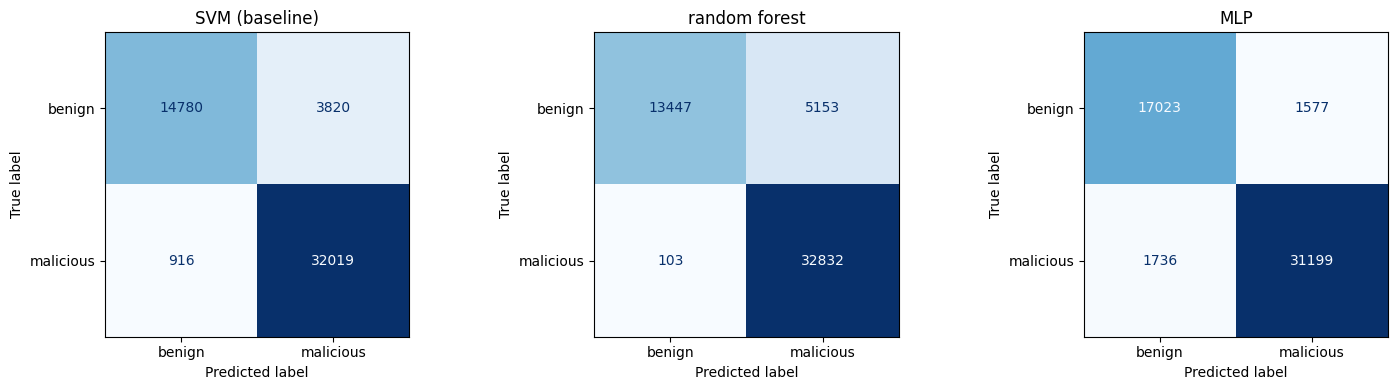

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=2,
    stratify=y
)

#get a smaller sample for testing (20000 used before)
X_train_svm, y_train_svm = get_subsample(X_train, y_train, size=10000, random_state=2)

svm_baseline = SVC(kernel='rbf', random_state=2, probability=True)
svm_baseline.fit(X_train_svm, y_train_svm)

best_rf.fit(X_train, y_train)
best_mlp.fit(X_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [svm_baseline, best_rf, best_mlp]
names = ['SVM (baseline)', 'random forest', 'MLP']

for ax, model, name in zip(axes, models, names):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['benign', 'malicious'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

Looking at the confusion matrices it is even more clear how good the random forest does on catching all malicious attacks, with only 103 missed of 32832. The drawback is that it has many false positives as a result.

Like we saw before MLP had much less false positives and negatives overall but was balanced between the number of them. For higher security envirnments this may be bad because it is better to have a higher number of false positives than false negatives.

The SVM is in between with less false positives than false negatives but with less incorrect labels than random forest and more than MLP.

<br>

Now lets look at the precision recall curves:

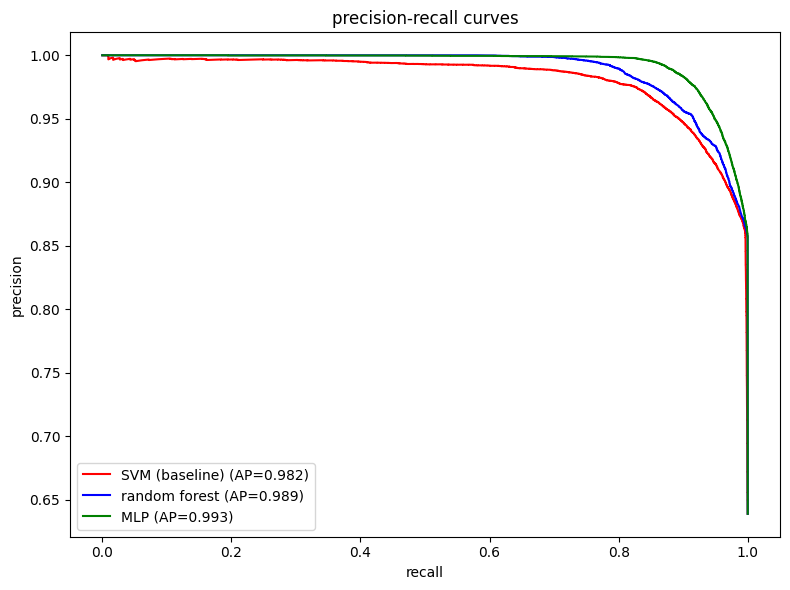

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['red', 'blue', 'green']

for model, name, color in zip(models, names, colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.3f})', color=color)

ax.set_xlabel('recall')
ax.set_ylabel('precision')
ax.set_title('precision-recall curves')
ax.legend()
plt.tight_layout()
plt.show()

All three of the curves quickly drop the precision once recall is at 1. This suggests that there are malicious cases that are overlapping normal traffic so much that they are not possible to catch without the accuracy going very low. This also suggests that extremely high recall should be avoided so that the model is not overfitting to this noise.

The curve also shows that MLP has higher precision and recall at different thresholds. To test I will try MLP at different thesholds to see if I can get an even higher recall, balanced accuracy, and fbeta score:

In [39]:
X_train_mlp, y_train_mlp = get_subsample(X_train, y_train, size=20000, random_state=2)
best_mlp.fit(X_train_mlp, y_train_mlp)
y_prob_mlp = best_mlp.predict_proba(X_test)[:, 1]
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

print(f"{'threshold':<12} {'accuracy':<12} {'balanced accuracy':<16} {'recall':<12} {'precision':<12} {'fbeta':<12}")
print("-" * 76)

for thresh in thresholds:
    y_pred_thresh = (y_prob_mlp >= thresh).astype(int)
    accuracy = accuracy_score(y_test, y_pred_thresh)
    baccuracy = balanced_accuracy_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    fbeta = fbeta_score(y_test, y_pred_thresh, beta=1.5)
    print(f"{thresh:<12} {accuracy:<12.4f} {baccuracy:<16.4f} {recall:<12.4f} {precision:<12.4f} {fbeta:<12.4f}")

threshold    accuracy     balanced accuracy recall       precision    fbeta       
----------------------------------------------------------------------------
0.5          0.9246       0.9207           0.9348       0.9466       0.9384      
0.4          0.9235       0.9114           0.9546       0.9277       0.9462      
0.3          0.9195       0.8988           0.9732       0.9075       0.9520      
0.2          0.9088       0.8781           0.9885       0.8828       0.9534      
0.1          0.9004       0.8635           0.9962       0.8676       0.9528      


This table shows that at lower thresholds like .3 and .2 MLP has better fbeta and balanced accuracy than random forest while still having a very high recall. This is better than the extremely high recall with lower accuracy from random forest. Overall, the MLP at the lower tresholds does better on every metric except recall (where it does slightly worse).

## Conclusion

Overall, I had a lot of fun doing this project and learned a lot about how difficult it is to evaluate which model is best given an imagined use case. If I had to pick what model I would use for a real intrusion detection system I would pick multi layer perceptron with a threshold of 0.2 as it had a very high recall of .9885 without sacrificing balanced accuracy as much as the random forest did (.8781). One of the main things I learned is how important it is to look not only at the accuracy when evaluating machine learning models but also looking at the precision recall curves, the confusion matrix, and the balanced accuracy (when classes are unbalanced).